In [ ]:
import xarray as xr
import s3fs
import contextily as cx
import matplotlib.pyplot as plt

# 1. read this or another url from the OSC or the EarthCODE STAC API
s3_path = "s3://EarthCODE/OSCAssets/eo4flood/Precipitation_zarr/EO4FLOOD_Precipitation_CHIRPS_dane.zarr/"
endpoint_url = "https://s3.waw4-1.cloudferro.com"

# open the dataset
fs = s3fs.S3FileSystem(anon=True, client_kwargs={'endpoint_url': endpoint_url})
mapper = fs.get_mapper(s3_path)
ds = xr.open_zarr(mapper, consolidated=False)

In [ ]:
# select the first time step and reproject to web mercator
precip_2d = ds.isel(time=0)

precip_2d = precip_2d.swap_dims({'latitude': 'lat', 'longitude': 'lon'})
precip_2d = precip_2d.set_coords(['lat', 'lon'])
precip_2d = precip_2d.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

precip_2d.rio.write_crs("EPSG:4326", inplace=True)
precip_3857 = precip_2d.rio.reproject("EPSG:3857")

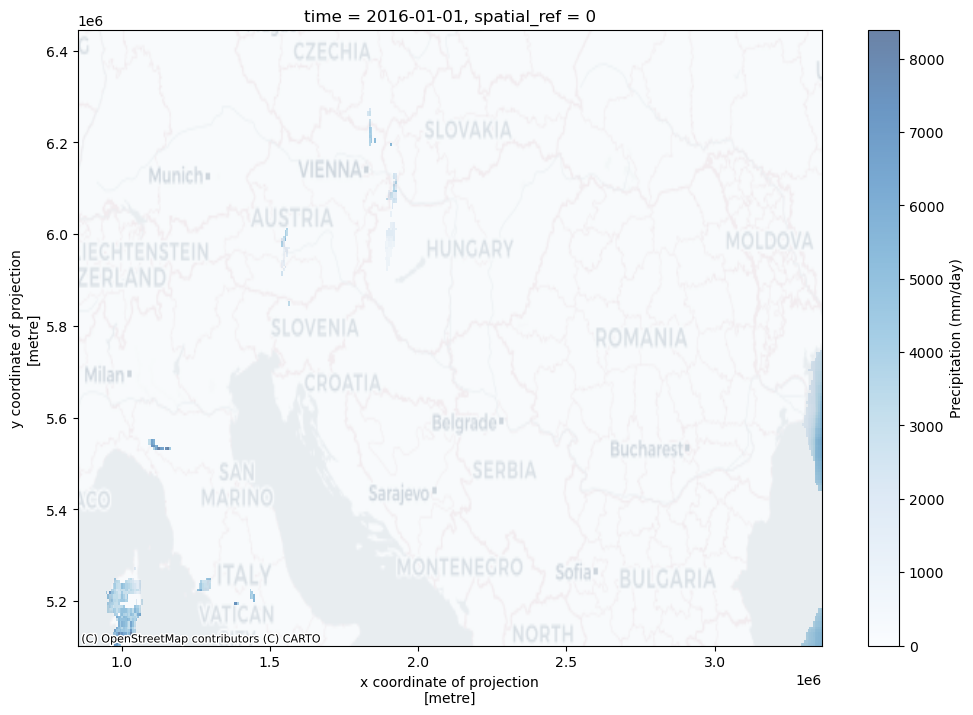

In [ ]:
#  create the plot
fig, ax = plt.subplots(figsize=(12, 8))
precip_3857.Precipitation.plot(
    ax=ax, 
    cmap="Blues", 
    alpha=0.6, 
    cbar_kwargs={"label": "Precipitation (mm/day)"}
)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)